## Final Project Code & Plots

Notebook containing analyses and figures for EESC 3376 final project write-up.

In my project, I focus on comparisons between observational (re-analysis) data and model historical outputs.  I conduct the following analyses.

1) Sea ice concentrations and the observed 2016-2017 anomaly.
2) Changes in time of ice coverage.

In [53]:
# imports
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import scipy.stats
import data_loader as dl
import pickle
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import cmocean

### Sea ice concentrations and the observed 2016-2017 anomaly.

In [52]:
# calculate 12-month rolling average
def rolling_avg(ts):
    avgs = []
    for i in tqdm(range(len(ts.time) - 12)):
        avgs.append(ts.isel(time=slice(i, i+12)).mean().values)
    return avgs

# z-score rolling averages
def z_score(ra):
    mu = np.mean(ra)
    sig = np.std(ra)

    ra_z = (ra - mu) / sig
    return ra_z

# plot spatially averaged time-series
def plot_obs_ts(obs_siconc_ts):
    fig, ax = plt.subplots(figsize=(10, 6))

    obs_siconc_ts.plot(ax=ax, color='steelblue')
    ax.set(xlabel='Year', ylabel='Sea Ice Concentration %', title='Observational Data Time-Series')
    ax.spines[['right', 'top']].set_visible(False)
    plt.savefig('figures/obs_siconc_ts.pdf', bbox_inches='tight')
    plt.show()

# plot rolling average time-series
def plot_obs_ra(data, y1, y2):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(np.linspace(y1, y2, 6 + (y2-y1) * 12), data)
    ax.set(xlabel='Year', ylabel='Sea Ice Concentration %', title='Observational Data, 12-month rolling average')
    ax.spines[['right', 'top']].set_visible(False)
    plt.savefig('figures/obs_siconc_ra_all_years.pdf', bbox_inches='tight')
    plt.show()

# plot mean and standard deviation of rolling averages
def plot_mu_sig(avg1, avg2, avg3, c1, c2, c3, l1, l2, l3, yl):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter([1], np.mean(avg1), color=c1)
    ax.errorbar([1], np.mean(avg1), yerr=np.std(avg1), ecolor=c1)
    ax.scatter([2], np.mean(avg2), color=c2)
    ax.errorbar([2], np.mean(avg2), yerr=np.std(avg2), ecolor=c2)

    ax.scatter([3], np.mean(avg3), color=c3)
    ax.errorbar([3], np.mean(avg3), yerr=np.std(avg3), ecolor=c3)
    
    ax.set(ylabel='Sea Ice Concentration %')
    ax.set_xticks([0.5, 1, 2, 3, 3.5], labels=['', l1, l2, l3, ''])
    ax.spines[['right', 'top']].set_visible(False)
    plt.savefig('figures/ra_mu_sig.pdf', bbox_inches='tight')
    plt.show()

# plot rolling averages of model historical and observational data
def plot_ra_obs_mh(obs_siconc_ra_z, mh_siconc_ra_z, anom_idx, obs_anom):
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(np.linspace(1971, 1971 + len(obs_siconc_ra_z)/12, len(obs_siconc_ra_z)), obs_siconc_ra_z, color='seagreen', label='Observational')
    ax.plot(np.linspace(1971, 1971 + len(mh_siconc_ra_z)/12, len(mh_siconc_ra_z)), mh_siconc_ra_z, color='plum', label='Model Historical')
    ax.plot(np.linspace(1971, 1971 + len(obs_siconc_ra_z)/12, len(obs_siconc_ra_z))[anom_idx], obs_anom, color='black', label='Observed Anomaly')
    ax.set(xlabel='Year', ylabel='Z-Score', title = 'Sea Ice Concentration: 1971 - Present')
    ax.legend()
    ax.spines[['right', 'top']].set_visible(False)
    plt.savefig('figures/obs_mh_ra_z.pdf', bbox_inches='tight')
    plt.show()

def plot_hist_stats_all(obs_siconc_ra_z, mh_siconc_ra_z, pic_siconc_ra_z):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [3, 1]})

    # histograms
    minimum = min(min(obs_siconc_ra_z), min(mh_siconc_ra_z), min(pic_siconc_ra_z))
    maximum = max(max(obs_siconc_ra_z), max(mh_siconc_ra_z), max(pic_siconc_ra_z))
    
    ax[0].hist(pic_siconc_ra_z, bins=np.arange(minimum, maximum+1, 0.1), density=True, color='dodgerblue', alpha=0.5, label='Pre-Industrial Control')
    ax[0].hist(mh_siconc_ra_z, bins=np.arange(minimum, maximum+1, 0.1), density=True, color='plum', alpha=0.5, label='Model Historical')
    ax[0].hist(obs_siconc_ra_z, bins=np.arange(minimum, maximum+1, 0.1), density=True, color='seagreen', alpha=0.5, label='Observational')

    ax[0].set(xlabel='Sea Ice Concentration Z-Score')            
    ax[0].legend()
    ax[0].grid()
    ax[0].spines[['right', 'top']].set_visible(False)

    # statistics
    t_obs_mh, p_obs_mh = scipy.stats.ttest_ind(obs_siconc_ra_z, mh_siconc_ra_z, equal_var=True, alternative='two-sided')
    t_obs_pic, p_obs_pic = scipy.stats.ttest_ind(obs_siconc_ra_z, pic_siconc_ra_z, equal_var=True, alternative='two-sided')
    t_mh_pic, p_mh_pic = scipy.stats.ttest_ind(mh_siconc_ra_z, pic_siconc_ra_z, equal_var=True, alternative='two-sided')

    ax[1].bar([1, 2, 3], [t_obs_mh, t_obs_pic, t_mh_pic], color=['peru', 'steelblue', 'darkmagenta'])
    ax[1].set_xticks([1, 2, 3], labels=['Obs - MH', 'Obs - PIC', 'MH - PIC'])
    #ax[1].set(ylabel = 't-statistic', ylim=[-0.00002, 0.0001])
    ax[1].set(ylabel = 't-statistic', ylim=[-0.0001, 0.0001])
    ax[1].spines[['right', 'top']].set_visible(False)
    plt.tight_layout()
    plt.savefig('figures/obs_mh_pic_hist.pdf', bbox_inches='tight')
    plt.show()

# plot histograms, calculate statistics
def plot_hist_stats_two_way(avg1, avg2, c1, c2, l1, l2, xl):
    fig, ax = plt.subplots(figsize=(8, 6))
    minimum = min(min(avg1), min(avg2))
    maximum = max(max(avg1), max(avg2))
    ax.hist(avg1, bins=np.arange(minimum, maximum+1, 0.1), density=False, color=c1, alpha=0.6, label=l1)    # setp = 0.1 if using obs, 0.2 otherwise
    ax.hist(avg2, bins=np.arange(minimum, maximum+1, 0.05), density=False, color=c2, alpha=0.6, label=l2)

    t, p = scipy.stats.ttest_ind(avg1, avg2, equal_var=True, alternative='two-sided')    # equal variance assumption since selecting out from samples

    if p < 0.05:
        ax.annotate('t = {:.3f}, \np = {:.3e}'.format(t, p),
                    xy=(0.05, 0.6), xycoords='axes fraction',
                    fontsize=14)
        ax.scatter([-2.85], [14], s=300, color='darkgoldenrod', marker='*')

    ax.set(xlabel=xl)            
    ax.legend()
    ax.grid()
    ax.spines[['right', 'top']].set_visible(False)
    plt.savefig('figures/anom_mh_hist.pdf', bbox_inches='tight')
    plt.show()

In [8]:
# observational data
path = 'MODEL.ICE.HAD187001-198110.OI198111-202206.nc'
obs_ds = xr.open_dataset(path)
obs_siconc = obs_ds.SEAICE

# select out Southern Ocean (south of 50S)
obs_siconc_so = obs_siconc.where(obs_siconc.lat <= -50)

# spatially average
obs_siconc_ts = obs_siconc_so.mean(dim=['lat', 'lon',])

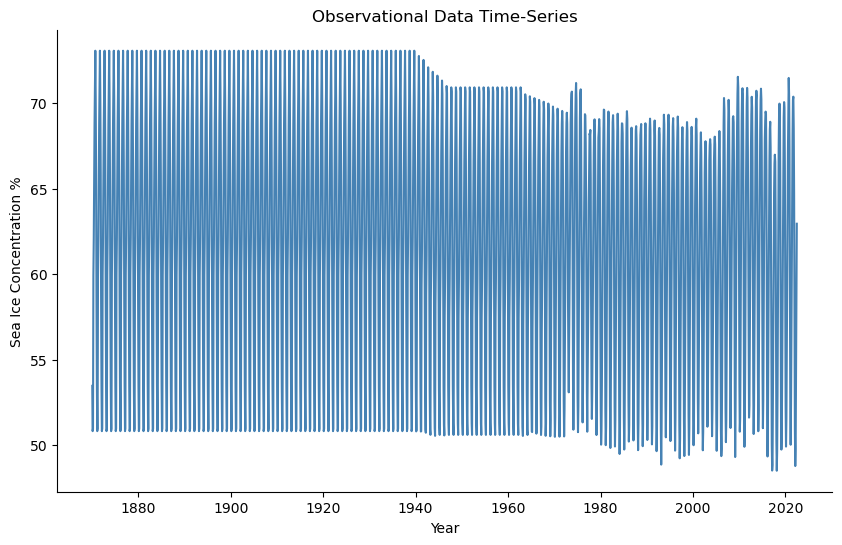

In [23]:
# plot spatially averaged observed sea ice concentration time-series
plot_obs_ts(obs_siconc_ts)

In [10]:
# calculate 12-month rolling averages
obs_siconc_ra = rolling_avg(obs_siconc_ts)

  0%|          | 0/1818 [00:00<?, ?it/s]

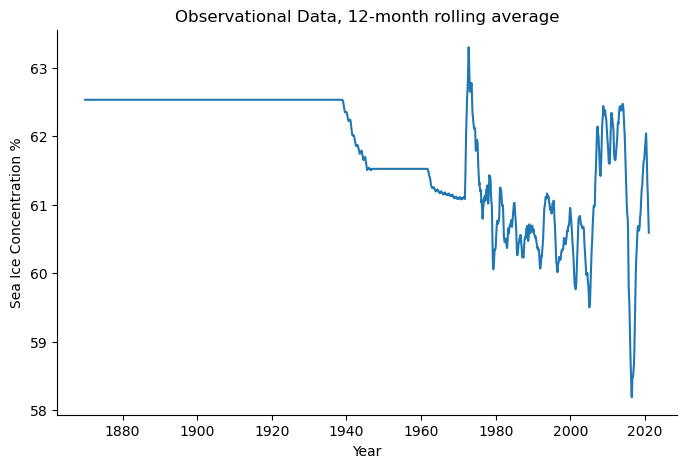

In [24]:
# plot 12-month rolling average of sea ice concentration observations
plot_obs_ra(obs_siconc_ra, 1870, 2021)

In [12]:
# select 1971-2021 (50 years), range that has valid observational data
obs_siconc_ra_50yrs = obs_siconc_ra[1212:]

# z-score
obs_siconc_ra_z = z_score(obs_siconc_ra_50yrs)

In [14]:
# model historical data
with open('rolling_avg_results/mh_siconc.pkl', 'rb') as f:
    mh_siconc_ra = pickle.load(f)

# pre-industrial control
with open('rolling_avg_results/pic_siconc.pkl', 'rb') as f:
    pic_siconc_ra = pickle.load(f)

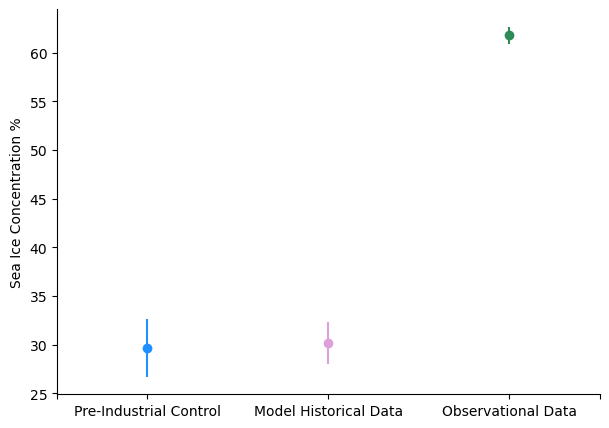

In [25]:
# plot mean and standard deviation of sea ice concentrations (over whole time ranges)
plot_mu_sig(pic_siconc_ra, mh_siconc_ra, obs_siconc_ra, 'dodgerblue', 'plum', 'seagreen', 'Pre-Industrial Control', 'Model Historical Data', 'Observational Data', 'Sea Ice Concentration %')

In [16]:
# select out from 1971 onwards (to match observations)
mh_siconc_ra_50yrs = mh_siconc_ra[1452:]

# z-score
mh_siconc_ra_z = z_score(mh_siconc_ra_50yrs)

In [17]:
# observational anomaly
obs_anom = obs_siconc_ra_z[obs_siconc_ra_z <= -3]
anom_idx = np.argwhere(obs_siconc_ra_z <= -3).T[0]

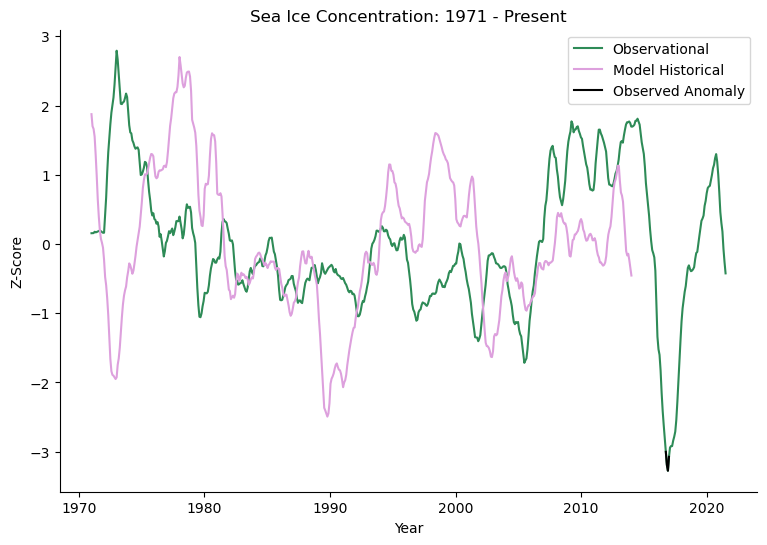

In [30]:
# plot z-scored rolling averges (data from 1971 onwards)
plot_ra_obs_mh(obs_siconc_ra_z, mh_siconc_ra_z, anom_idx, obs_anom)

In [34]:
# z-score entire model historical rolling average
mh_siconc_ra_z_all_years = z_score(mh_siconc_ra)

# z-score all pre-industrial control data
pic_siconc_ra_z = z_score(pic_siconc_ra)

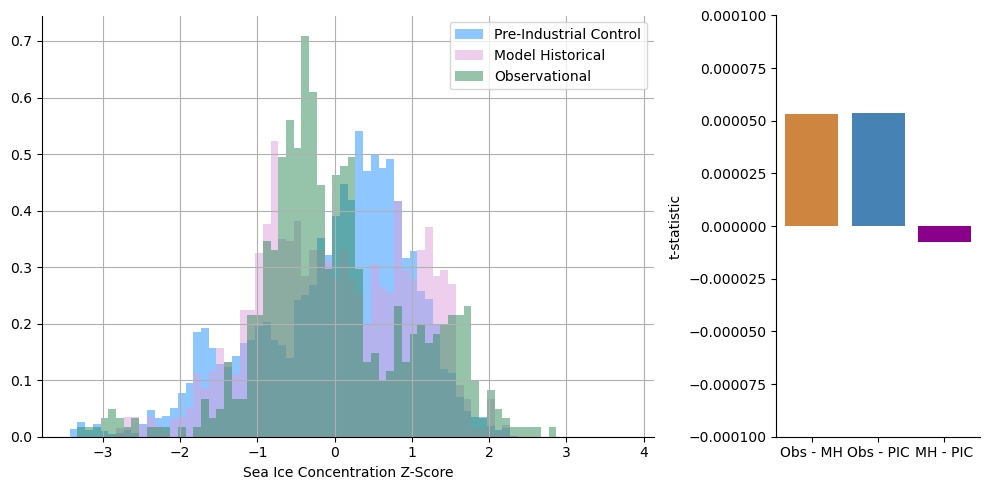

In [45]:
# plot histogram comparing observations since 1971, entire model history and entire pre-industrial control
plot_hist_stats_all(obs_siconc_ra_z, mh_siconc_ra_z_all_years, pic_siconc_ra_z)

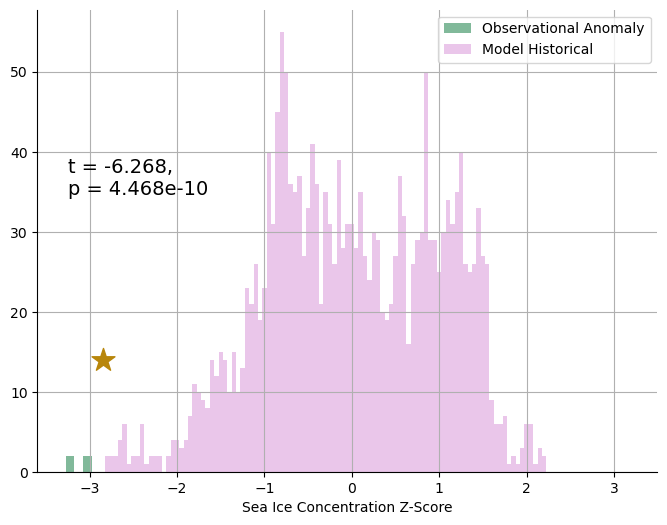

In [51]:
# plot histogram of anomaly vs. all model history
plot_hist_stats_two_way(obs_anom, mh_siconc_ra_z_all_years, 'seagreen', 'plum', 'Observational Anomaly', 'Model Historical', 'Sea Ice Concentration Z-Score')

### Changes in time of ice coverage

In [88]:
def plot_sitimefrac(data):
    plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
    ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())
    
    # add some map features
    ax.add_feature(cfeature.LAND, zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    # add gridline
    gl = ax.gridlines(
        xlocs = np.arange(-180,180,30),
        ylocs = np.arange(-90,90,20))
    
    # use pcolormesh to plot the 2D array
    im = ax.pcolormesh(data.lon, data.lat, data, # x, y, data
                       transform=ccrs.PlateCarree(), # indicate the coordinate system
                       cmap=cmocean.cm.ice) # use colormap from cmocean
    
    cbar = plt.colorbar(im, label='Proportion of Time with Ice Coverage', shrink=0.7) # plot colorbar

    ax.set(title='Model: Time Average (1950 - 2014)')
    plt.savefig('figures/sitimefrac_tavg.pdf', bbox_inches='tight')
    plt.show()

def plot_sitimefrac_betas(betas, ya, vmn, vmx, ttl, savepath):
    plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.SouthPolarStereo())  # Polar stereographic projection
    ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())
    
    # add gridline
    gl = ax.gridlines(
        xlocs = np.arange(-180,180,30),
        ylocs = np.arange(-90,90,20),
        draw_labels=True, y_inline=True)
    
    # use pcolormesh to plot the 2D array
    im = ax.pcolormesh(ya.lon, ya.lat, betas.polyfit_coefficients[0], # x, y, data
                       transform=ccrs.PlateCarree(), # indicate the coordinate system
                       #cmap='RdBu',
                       #cmap = cmocean.cm.ice,
                       cmap='twilight_shifted_r',
                       vmin=vmn, vmax=vmx) # use colormap from cmocean

    # add some map features
    ax.add_feature(cfeature.LAND, zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    cbar = plt.colorbar(im, label='Slope of Linear Regression', shrink=0.7) # plot colorbar

    ax.set(title=ttl)
    plt.savefig(f'figures/{savepath}.pdf', bbox_inches='tight')
    plt.show()

In [56]:
# sitimefrac
ds_sitimefrac = dl.sea_ice_timesteps()
data_sitimefrac = ds_sitimefrac.sitimefrac

# time average
sitfrac_tavg = data_sitimefrac.mean(dim='time')

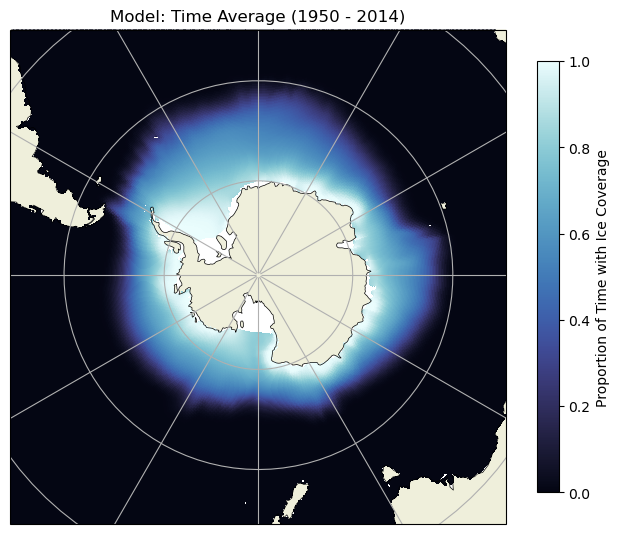

In [64]:
# plot averge over time of ice coverage time proportions
plot_sitimefrac(sitfrac_tavg)

In [65]:
### calculate yearly average
ya = data_sitimefrac.groupby('time.year').mean('time')

# fit linear regression
betas = ya.polyfit(dim='year', deg=1)#, skipna=True)

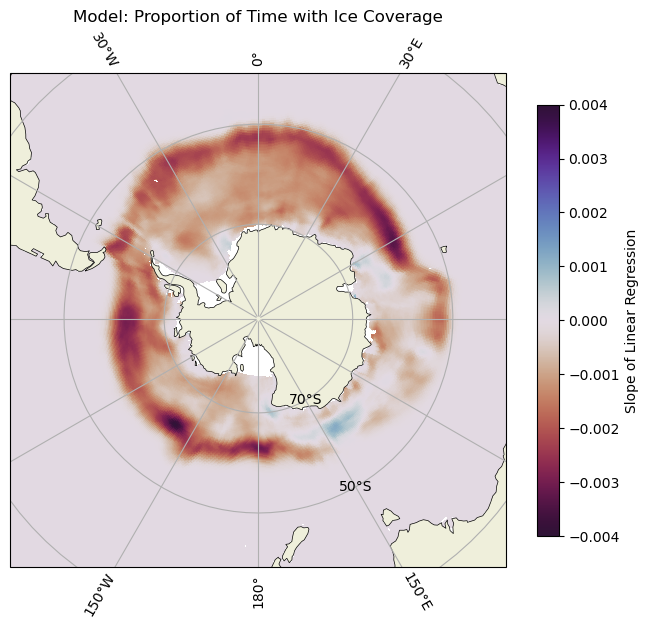

In [89]:
# plot slopes of yearly ice coverage time proportions
plot_sitimefrac_betas(betas, ya, -0.004, 0.004, 'Model: Proportion of Time with Ice Coverage', 'ice_cov_time_model')

In [85]:
# select out 1971 onwards (valid observations)
# don't use data from 5 months of 2022 (biases yearly averages
obs_siconc_valid = obs_siconc.sel(time=slice('1971', '2021'))

# average sea ice concentration for each spatial position
mu_t = obs_siconc_valid.mean(dim=['time'])

# difference from time average
obs_siconc_anom = obs_siconc_valid - mu_t

# metric of sea ice coverage
# 1 if above average concentration, 0 if below
obs_sitimefrac = xr.where(obs_siconc_anom > 0, 1, 0)

### calculate yearly average
obs_ya = obs_sitimefrac.groupby('time.year').mean('time')

# fit linear regression
obs_betas = obs_ya.polyfit(dim='year', deg=1)#, skipna=True)

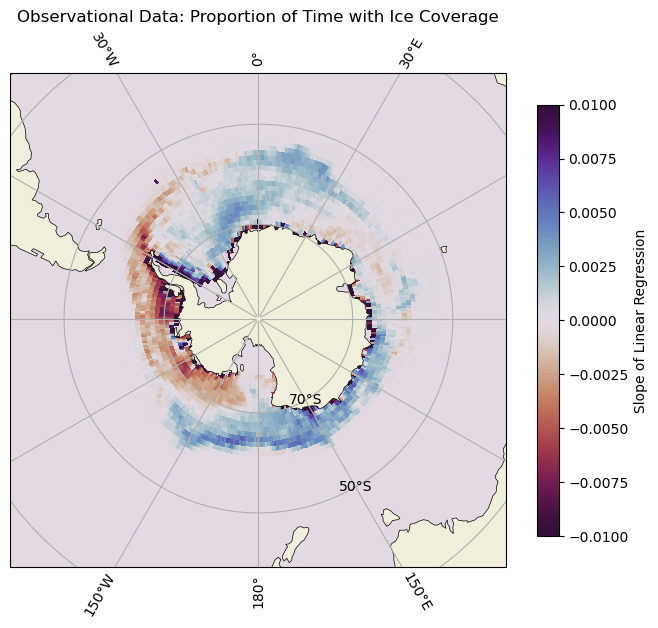

In [90]:
plot_sitimefrac_betas(obs_betas, obs_ya, -0.01, 0.01, 'Observational Data: Proportion of Time with Ice Coverage', 'ice_cov_time_obs')

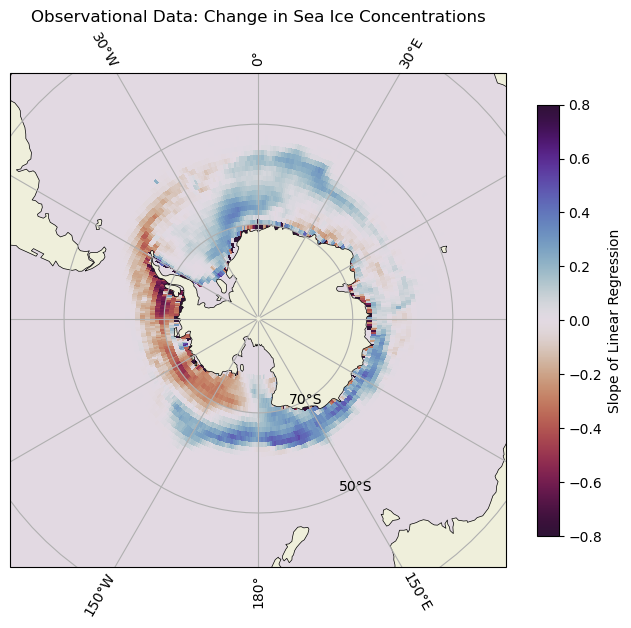

In [91]:
# also run analyses with just sea ice concentration (no transformation)
ya_siconc = obs_siconc_valid.groupby('time.year').mean('time')

# fit linear regression
betas_siconc = ya_siconc.polyfit(dim='year', deg=1)

plot_sitimefrac_betas(betas_siconc, ya_siconc, -0.8, 0.8, 'Observational Data: Change in Sea Ice Concentrations', 'siconc_obs_betas')